In [1]:
#import necessary module
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc ,recall_score, f1_score, r2_score
from sklearn.model_selection import GridSearchCV

In [3]:
#LOAD DATA
df = pd.read_csv("diabetes_risk.csv")
df.columns = df.columns.str.strip()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               7608 non-null   float64
 1   Glucose                   7586 non-null   float64
 2   BloodPressure             7632 non-null   float64
 3   SkinThickness             7610 non-null   float64
 4   Insulin                   8000 non-null   float64
 5   BMI                       7618 non-null   float64
 6   DiabetesPedigreeFunction  7577 non-null   float64
 7   Age                       7612 non-null   float64
 8   Outcome                   7611 non-null   float64
dtypes: float64(9)
memory usage: 562.6 KB


In [4]:
print("Initial Shape:", df.shape)
print("Columns:", df.columns)

Initial Shape: (8000, 9)
Columns: Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


In [5]:
#REPLACE ZERO WITH NaN
coloumns_with_zero= ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Age']

for col in coloumns_with_zero:
    if col in df.columns:
        df[col] = df[col].replace(0, np.nan)

In [6]:
#DATA PREPROCESSING
# HANDLE INVALID VALUES

# Age cannot be <= 0
df.loc[df['Age'] <= 0, 'Age'] = np.nan

# BMI cannot be 0 or negative
df.loc[df['BMI'] <= 0, 'BMI'] = np.nan

# Glucose cannot be 0
if 'Glucose' in df.columns:
    df.loc[df['Glucose'] <= 0, 'Glucose'] = np.nan

# Insulin cannot be 0 (in medical context)
if 'Insulin' in df.columns:
    df.loc[df['Insulin'] <= 0, 'Insulin'] = np.nan

# BloodPressure cannot be 0
if 'BloodPressure' in df.columns:
    df.loc[df['BloodPressure'] <= 0, 'BloodPressure'] = np.nan

# SkinThickness cannot be 0
if 'SkinThickness' in df.columns:
    df.loc[df['SkinThickness'] <= 0, 'SkinThickness'] = np.nan


In [7]:
# REMOVE NEGATIVE VALUES
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    df.loc[df[col] < 0, col] = np.nan

In [8]:
# HANDLE MISSING VALUES
# Fill with median (better for medical data)
df.fillna(df.median(numeric_only=True), inplace=True)

In [9]:
# CAP OUTLIERS (Better than removing rows)

def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[column] = np.where(df[column] < lower, lower, df[column])
    df[column] = np.where(df[column] > upper, upper, df[column])

# Apply safely
columns_to_clean = ['Age', 'BMI']

if 'Glucose' in df.columns:
    columns_to_clean.append('Glucose')
if 'Insulin' in df.columns:
    columns_to_clean.append('Insulin')

for col in columns_to_clean:
    cap_outliers(df, col)

In [10]:
#  FINAL CHECK
print("Final Shape:", df.shape)
print(df.describe())

Final Shape: (8000, 9)
       Pregnancies      Glucose  BloodPressure  SkinThickness      Insulin  \
count  8000.000000  8000.000000    8000.000000    8000.000000  8000.000000   
mean      3.820125   121.510375      72.476125      29.149750   139.517875   
std       3.276753    29.682821      11.835083       8.661406    61.105118   
min       0.000000    44.000000      24.000000       7.000000    14.000000   
25%       1.000000   100.000000      65.000000      26.000000    96.000000   
50%       3.000000   117.000000      72.000000      29.000000   133.000000   
75%       6.000000   139.000000      80.000000      32.000000   176.000000   
max      17.000000   197.500000     122.000000      99.000000   296.000000   

               BMI  DiabetesPedigreeFunction         Age      Outcome  
count  8000.000000               8000.000000  8000.00000  8000.000000  
mean     32.457925                  0.471530    33.06875     0.337250  
std       6.417359                  0.328573    11.31140  

In [11]:
# Count the number of occurrences of each class in the 'Outcome' column
print(df['Outcome'].value_counts())
print(df['Outcome'].value_counts(normalize=True) * 100)

Outcome
0.0    5302
1.0    2698
Name: count, dtype: int64
Outcome
0.0    66.275
1.0    33.725
Name: proportion, dtype: float64


In [12]:
#inf0rmation
df.info

<bound method DataFrame.info of       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0             0.0    125.0           72.0           29.0    182.0  22.5   
1             0.0    141.0           72.0           29.0    131.0  42.4   
2            10.0    101.0           86.0           37.0    172.0  45.6   
3             1.0     96.0           72.0           29.0     94.0  22.4   
4             5.0    139.0           64.0           35.0    140.0  28.6   
...           ...      ...            ...            ...      ...   ...   
7995          1.0    117.0           74.0           11.0     60.0  30.0   
7996          3.0     83.0           58.0           31.0     18.0  34.3   
7997          0.0    102.0           86.0           17.0    105.0  29.3   
7998          3.0    124.0           80.0           33.0    130.0  33.2   
7999          1.0    146.0           56.0           29.0    105.0  29.7   

      DiabetesPedigreeFunction   Age  Outcome  
0                  

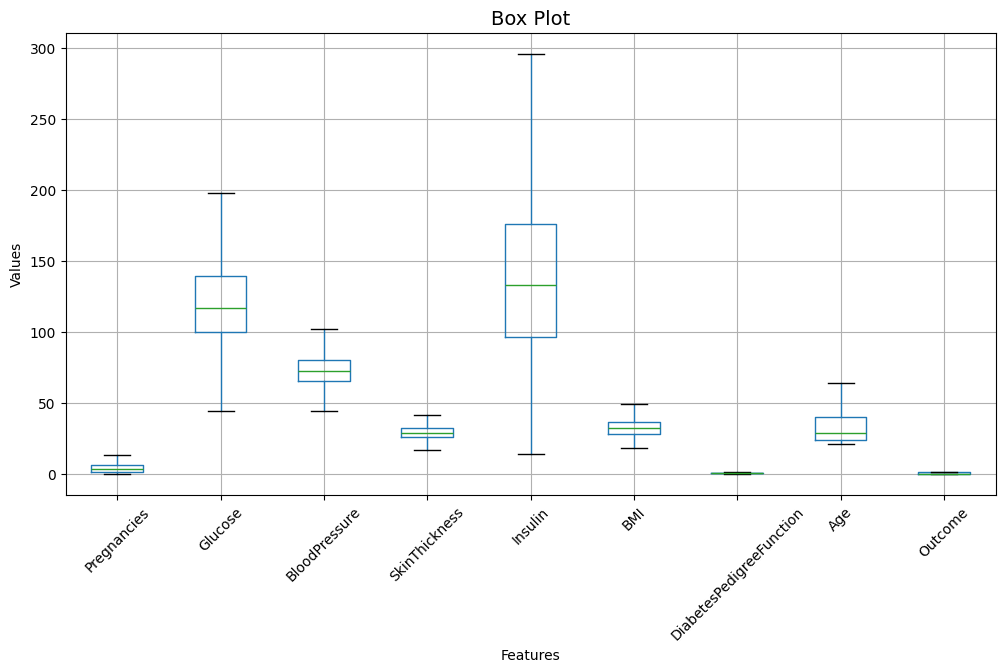

In [13]:
#Shows distribution
plt.figure(figsize=(12,6))

df.boxplot(showfliers=False)

plt.title("Box Plot", fontsize=14)
plt.xlabel("Features")
plt.ylabel("Values")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

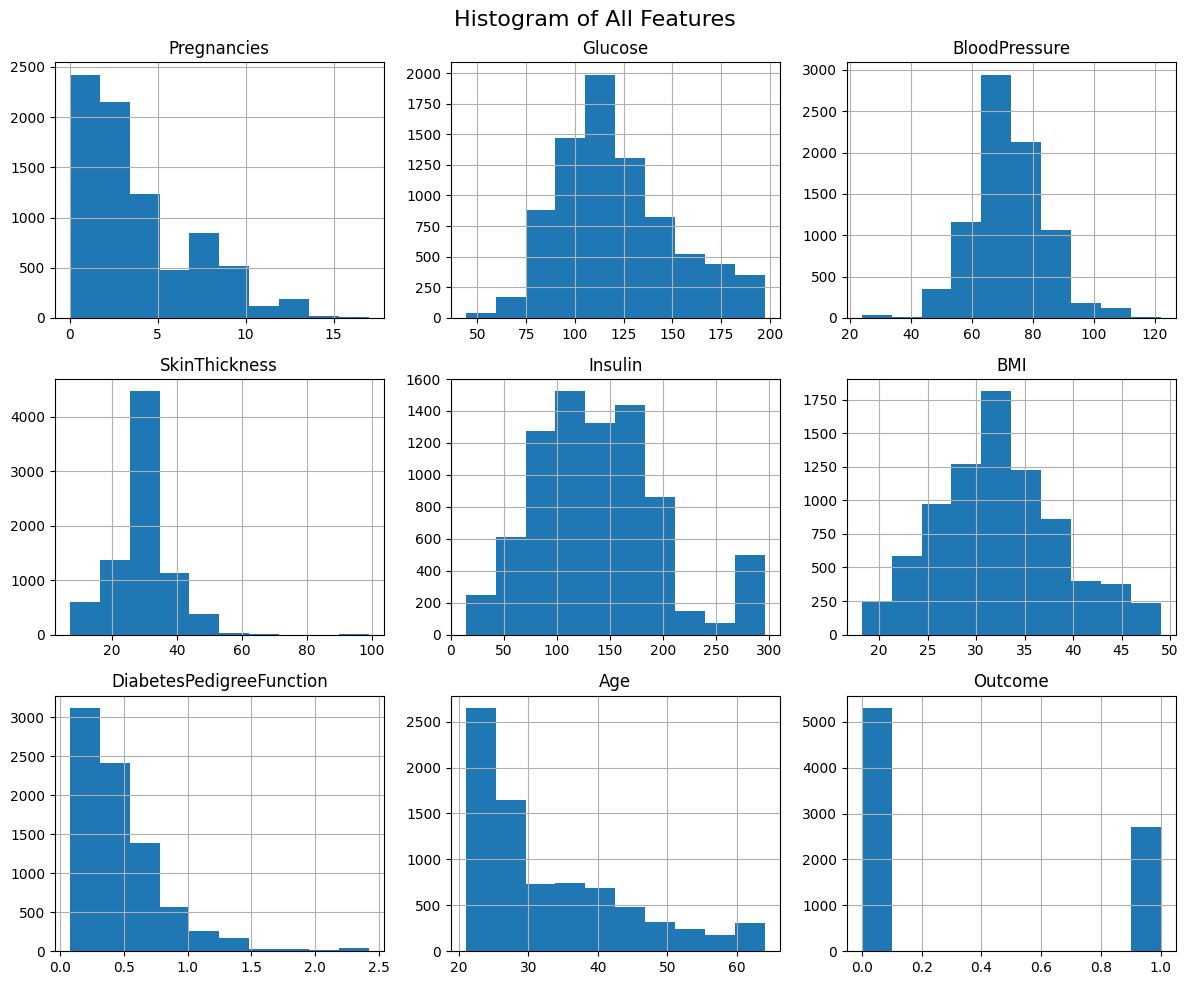

In [14]:
#Shows data distribution and skewness.
df.hist(figsize=(12,10))

plt.suptitle("Histogram of All Features", fontsize=16)

plt.tight_layout()
plt.show()

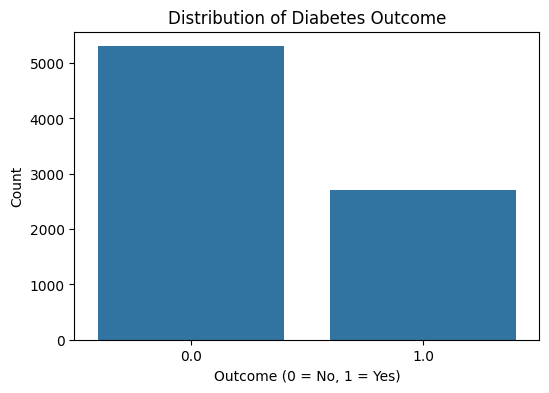

In [15]:
#outcome distribution for the dataset
plt.figure(figsize=(6,4))

sns.countplot(x='Outcome', data=df)

plt.title("Distribution of Diabetes Outcome")
plt.xlabel("Outcome (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.show()